# ABIDES Declarative Configuration System — Tutorial

This notebook demonstrates the **declarative configuration system** for ABIDES market simulations.  
Instead of writing procedural `build_config()` functions, you can:

- Build simulations from **composable templates**
- **Enable/disable agent types** with a fluent API
- Set **per-agent computation delays**
- **Serialize** configs as YAML or JSON
- **Register custom agents** with the plugin registry
- Use the **AI discoverability API** for programmatic introspection

📖 Full reference: [`docs/ABIDES_CONFIG_SYSTEM.md`](../docs/ABIDES_CONFIG_SYSTEM.md)

In [22]:
import pathlib
import sys

# Add ABIDES packages to path (assumes notebook is in <workspace>/notebooks/)
_ws = pathlib.Path().resolve()
if _ws.name == "notebooks":
    _ws = _ws.parent
for _pkg in ("abides-core", "abides-markets"):
    _p = str(_ws / _pkg)
    if _p not in sys.path:
        sys.path.insert(0, _p)

In [23]:
import json
import tempfile
from pathlib import Path

import numpy as np
import pandas as pd
from abides_core import abides
from abides_core.utils import fmt_ts, ns_date, str_to_ns
from abides_markets.config_system import (
    BaseAgentConfig,
    SimulationBuilder,
    compile,
    config_to_dict,
    get_config_schema,
    list_agent_types,
    list_templates,
    load_config,
    register_agent,
    registry,
    save_config,
    validate_config,
)
from matplotlib import pyplot as plt

---
## 1. Quick Start — Build, Compile, Run

The three-step workflow:
1. **Build** a `SimulationConfig` using the `SimulationBuilder`
2. **Compile** it into the runtime dict the `Kernel` expects
3. **Run** the simulation with `abides.run()`

> **Note:** `abides.run()` deep-copies the agents and oracle before each run,
> so you can safely re-execute the run cell on the same `runtime` dict and get
> identical results every time.

In [ ]:
# Build a config from the rmsc04 template
config = (
    SimulationBuilder()
    .from_template("rmsc04")
    .market(ticker="ABM")
    .seed(42)
    .build()
)

print(f"Ticker: {config.market.ticker}")
print(f"Date: {config.market.date}")
print(f"Trading hours: {config.market.start_time} — {config.market.end_time}")
print(f"Seed: {config.simulation.seed}")
print(f"Agent groups: {list(config.agents.keys())}")

Ticker: ABM
Date: 20210205
Trading hours: 09:30:00 — 16:00:00
Seed: 42
Agent groups: ['noise', 'value', 'momentum', 'adaptive_market_maker']


In [25]:
# Compile to a runtime dict
runtime = compile(config)

print(f"Runtime dict keys: {list(runtime.keys())}")
print(f"Total agents: {len(runtime['agents'])}")
print(f"Default computation delay: {runtime['default_computation_delay']} ns")

Runtime dict keys: ['seed', 'start_time', 'stop_time', 'agents', 'agent_latency_model', 'default_computation_delay', 'custom_properties', 'random_state_kernel', 'stdout_log_level']
Total agents: 1117
Default computation delay: 50 ns


In [26]:
# Run the simulation
end_state = abides.run(runtime)

print(f"Simulation completed. Agents in end_state: {len(end_state['agents'])}")

[24744] INFO abides Simulation Start Time: 2026-03-20 15:50:53.277210
[24744] INFO abides_core.kernel --- Simulation time: 2021-02-05 00:00:00, messages processed: 0, wallclock elapsed: 0.00s ---
[24744] INFO abides_core.kernel --- Simulation time: 2021-02-05 10:33:26, messages processed: 100,000, wallclock elapsed: 2.00s ---
[24744] INFO abides_core.kernel --- Simulation time: 2021-02-05 11:40:00, messages processed: 200,000, wallclock elapsed: 4.51s ---
[24744] INFO abides_core.kernel --- Simulation time: 2021-02-05 12:26:54, messages processed: 300,000, wallclock elapsed: 6.57s ---
[24744] INFO abides_core.kernel --- Simulation time: 2021-02-05 13:21:50, messages processed: 400,000, wallclock elapsed: 8.98s ---
[24744] INFO abides_core.kernel --- Simulation time: 2021-02-05 14:37:38, messages processed: 500,000, wallclock elapsed: 14.02s ---
[24744] INFO abides_core.kernel --- Simulation time: 2021-02-05 15:53:58, messages processed: 600,000, wallclock elapsed: 19.21s ---
[24744] IN

Simulation completed. Agents in end_state: 1117


---
## 2. Templates — Composable Starting Points

Templates provide sensible defaults for common simulation scenarios.  
**Base templates** define a full configuration; **overlay templates** add agent groups on top.

In [27]:
# List all available templates
templates = list_templates()
for t in templates:
    overlay = " (overlay)" if t["is_overlay"] else ""
    print(f"  {t['name']}{overlay}: {t['description']}")

  rmsc04: Reference Market Simulation Configuration #4: 1 Exchange, 2 Market Makers, 102 Value Agents, 12 Momentum Agents, 1000 Noise Agents.
  liquid_market: High-liquidity market: 5000 Noise, 200 Value, 25 Momentum, 4 Market Makers.
  thin_market: Low-liquidity market: 100 Noise, 20 Value, no market makers or momentum.
  with_momentum (overlay): Overlay: adds 12 Momentum agents.
  with_execution (overlay): Overlay: adds 1 POV Execution agent.


### Template stacking

You can stack multiple templates — later ones override earlier ones.  
Here we start with `rmsc04` and add a POV execution agent via the `with_execution` overlay:

In [28]:
config_stacked = (
    SimulationBuilder()
    .from_template("rmsc04")
    .from_template("with_execution")  # adds a POV execution agent
    .seed(42)
    .build()
)

print("Agent groups after stacking:")
for name, group in config_stacked.agents.items():
    status = "enabled" if group.enabled else "disabled"
    print(f"  {name}: {group.count} agents ({status})")

Agent groups after stacking:
  noise: 1000 agents (enabled)
  value: 102 agents (enabled)
  momentum: 12 agents (enabled)
  adaptive_market_maker: 2 agents (enabled)
  pov_execution: 1 agents (enabled)


---
## 3. Builder API — Fine-Grained Control

The fluent builder lets you override any parameter:

In [29]:
config_custom = (
    SimulationBuilder()
    .from_template("rmsc04")
    .market(ticker="AAPL", date="20220315", end_time="11:00:00")
    .oracle(r_bar=150_000)                        # $1500.00 fundamental
    .exchange(book_log_depth=20)
    .enable_agent("noise", count=500)              # fewer noise agents
    .enable_agent("value", count=50, r_bar=150_000)
    .disable_agent("momentum")                     # no momentum agents
    .computation_delay(100)                        # global default: 100ns
    .seed(123)
    .log_orders(True)
    .build()
)

print(f"Ticker: {config_custom.market.ticker}")
print(f"Oracle r_bar: ${config_custom.market.oracle.r_bar / 100:.2f}")
print(f"Noise agents: {config_custom.agents['noise'].count}")
print(f"Value agents: {config_custom.agents['value'].count}")
print(f"Momentum enabled: {config_custom.agents['momentum'].enabled}")
print(f"Default computation delay: {config_custom.infrastructure.default_computation_delay} ns")

Ticker: AAPL
Oracle r_bar: $1500.00
Noise agents: 500
Value agents: 50
Momentum enabled: False
Default computation delay: 100 ns


---
## 4. Per-Agent Computation Delays

Different agent types can have different "thinking times".  
Market makers might be fast (low delay) while background noise agents are slow (high delay).  
The `computation_delay` parameter overrides the simulation-level default **per agent group**.

In [30]:
from collections import Counter

config_delays = (
    SimulationBuilder()
    .from_template("rmsc04")
    .computation_delay(50)                                       # global default
    .enable_agent("adaptive_market_maker", count=2,
                  computation_delay=10)                          # fast MM
    .enable_agent("noise", count=1000, computation_delay=500)   # slow noise
    .enable_agent("value", count=102)                            # uses global default (50ns)
    .seed(42)
    .build()
)

runtime_delays = compile(config_delays)

# Show the per-agent overrides
per_agent = runtime_delays.get("per_agent_computation_delays", {})
print(f"Global default: {runtime_delays['default_computation_delay']} ns")
print(f"Agents with custom delays: {len(per_agent)}")

# Summarize by agent type
delay_values = Counter(per_agent.values())
for delay, count in sorted(delay_values.items()):
    print(f"  {count} agents with {delay} ns delay")

Global default: 50 ns
Agents with custom delays: 1002
  2 agents with 10 ns delay
  1000 agents with 500 ns delay


You can also use the convenience method `agent_computation_delay()` on the builder:

In [31]:
# Equivalent: set computation delay for a specific agent type
config_alt = (
    SimulationBuilder()
    .from_template("rmsc04")
    .agent_computation_delay("noise", 500)
    .agent_computation_delay("adaptive_market_maker", 10)
    .seed(42)
    .build()
)

print(f"Noise delay: {config_alt.agents['noise'].params.get('computation_delay')} ns")
print(f"MM delay: {config_alt.agents['adaptive_market_maker'].params.get('computation_delay')} ns")

Noise delay: 500 ns
MM delay: 10 ns


---
## 5. Agent Registry — Discover & Extend

All built-in agent types are self-registered. You can discover them programmatically.

In [32]:
# List all registered agent types
agent_types = list_agent_types()

print(f"{'Name':<25} {'Category':<15} {'Description'}")
print("-" * 80)
for a in agent_types:
    print(f"{a['name']:<25} {a['category']:<15} {a.get('description', '')}")

Name                      Category        Description
--------------------------------------------------------------------------------
noise                     background      Simple agent that wakes once at a random time and places one random limit order at bid or ask.
value                     background      Bayesian learner that estimates fundamental value from noisy observations and trades when price deviates from estimate.
momentum                  strategy        Trend-follower using 20-bar vs 50-bar moving average crossover. Buys when MA(20) >= MA(50), sells otherwise.
adaptive_market_maker     market_maker    Market maker using inventory-skewed ladder strategy with adaptive spread. Places liquidity on both sides in multiple price levels.
pov_execution             execution       Percentage-of-volume execution agent that sizes orders based on observed transacted volume to execute a large target quantity.
my_custom_noise           background      Custom noise agent with configu

In [33]:
# Inspect parameters for a specific agent type
schema = registry.get_json_schema("value")
print("ValueAgent parameters:")
for name, prop in schema["properties"].items():
    desc = prop.get("description", "")
    default = prop.get("default", "—")
    print(f"  {name}: default={default}  ({desc})")

ValueAgent parameters:
  starting_cash: default=10000000  (Initial cash in cents ($100k = 10_000_000).)
  log_orders: default=None  (Override per-agent order logging. None = use simulation-level setting.)
  computation_delay: default=None  (Per-agent-type computation delay in nanoseconds. None = use the simulation-level default_computation_delay.)
  r_bar: default=100000  (True mean fundamental value in cents.)
  kappa: default=1.67e-15  (Mean-reversion coefficient for agent's appraisal.)
  lambda_a: default=5.7e-12  (Arrival rate (per nanosecond) for Poisson wakeups.)
  sigma_n: default=None  (Observation noise variance. Defaults to r_bar / 100.)


### Registering a custom agent

Third-party agents can be registered with `@register_agent` and used in configs just like built-in ones.  
The config model must extend `BaseAgentConfig` and implement `create_agents()`.

In [34]:
from pydantic import Field

_CUSTOM_DESC = "Custom noise agent with configurable threshold"


@register_agent("my_custom_noise", category="background", description=_CUSTOM_DESC)
class MyCustomNoiseConfig(BaseAgentConfig):
    """Custom noise agent that wraps the built-in NoiseAgent."""

    threshold: float = Field(default=0.05, description="Custom threshold.")

    def create_agents(self, count, id_start, master_rng, context):
        from abides_core.utils import get_wake_time, str_to_ns
        from abides_markets.agents import NoiseAgent

        log = self.log_orders if self.log_orders is not None else context.log_orders
        noise_mkt_open = context.mkt_open + str_to_ns("-00:30:00")
        date_ns = context.mkt_open - str_to_ns("09:30:00")
        noise_mkt_close = date_ns + str_to_ns("16:00:00")

        agents = []
        for j in range(id_start, id_start + count):
            rng = np.random.RandomState(
                seed=master_rng.randint(low=0, high=2**32, dtype="uint64")
            )
            agents.append(
                NoiseAgent(
                    id=j,
                    name=f"MyCustomNoise_{j}",
                    type="MyCustomNoiseAgent",
                    symbol=context.ticker,
                    starting_cash=self.starting_cash,
                    wakeup_time=get_wake_time(
                        noise_mkt_open, noise_mkt_close, rng
                    ),
                    log_orders=log,
                    random_state=rng,
                )
            )
        return agents


print("Custom agent registered!")
print(f"Registered types: {registry.registered_names()}")

Custom agent registered!
Registered types: ['adaptive_market_maker', 'momentum', 'my_custom_noise', 'noise', 'pov_execution', 'value']


In [35]:
# Use the custom agent in a simulation
config_custom_agent = (
    SimulationBuilder()
    .from_template("rmsc04")
    .enable_agent("my_custom_noise", count=10, threshold=0.1)
    .seed(42)
    .build()
)

runtime_custom = compile(config_custom_agent)
print(f"Total agents (1117 rmsc04 + 10 custom): {len(runtime_custom['agents'])}")

Total agents (1117 rmsc04 + 10 custom): 1127


---
## 6. Serialization — YAML & JSON

Configs can be saved to YAML or JSON and loaded back. This is useful for:
- Sharing experiment configurations
- Version-controlling simulation setups
- Parameter sweeps from config files

In [36]:
# Save to YAML
config_to_save = (
    SimulationBuilder()
    .from_template("rmsc04")
    .market(ticker="AAPL")
    .enable_agent("noise", count=500, computation_delay=200)
    .seed(42)
    .build()
)

yaml_path = Path(tempfile.gettempdir()) / "abides_config_demo.yaml"
save_config(config_to_save, yaml_path)

# Display the YAML content
print(yaml_path.read_text())

market:
  ticker: AAPL
  date: '20210205'
  start_time: 09:30:00
  end_time: '10:00:00'
  oracle:
    type: sparse_mean_reverting
    r_bar: 100000
    kappa: 1.67e-16
    sigma_s: 0.0
    fund_vol: 5.0e-05
    megashock_lambda_a: 2.77778e-18
    megashock_mean: 1000.0
    megashock_var: 50000.0
  exchange:
    book_logging: true
    book_log_depth: 10
    stream_history_length: 500
    log_orders: false
    pipeline_delay: 0
    computation_delay: 0
agents:
  noise:
    enabled: true
    count: 500
    params:
      computation_delay: 200
  value:
    enabled: true
    count: 102
    params:
      r_bar: 100000
      kappa: 1.67e-15
      lambda_a: 5.7e-12
  momentum:
    enabled: true
    count: 12
    params:
      min_size: 1
      max_size: 10
      wake_up_freq: 37s
  adaptive_market_maker:
    enabled: true
    count: 2
    params:
      pov: 0.025
      min_order_size: 1
      window_size: adaptive
      num_ticks: 10
      wake_up_freq: 60s
      skew_beta: 0
      price_skew_

In [37]:
# Load it back and verify
loaded = load_config(yaml_path)

print(f"Loaded ticker: {loaded.market.ticker}")
print(f"Loaded noise agent count: {loaded.agents['noise'].count}")
print(f"Loaded noise computation_delay: {loaded.agents['noise'].params.get('computation_delay')}")
print(f"Loaded seed: {loaded.simulation.seed}")

Loaded ticker: AAPL
Loaded noise agent count: 500
Loaded noise computation_delay: 200
Loaded seed: 42


In [38]:
# JSON works too
json_path = Path(tempfile.gettempdir()) / "abides_config_demo.json"
save_config(config_to_save, json_path)

d = config_to_dict(config_to_save)
print(json.dumps(d, indent=2)[:500], "...")

{
  "market": {
    "ticker": "AAPL",
    "date": "20210205",
    "start_time": "09:30:00",
    "end_time": "10:00:00",
    "oracle": {
      "type": "sparse_mean_reverting",
      "r_bar": 100000,
      "kappa": 1.67e-16,
      "sigma_s": 0.0,
      "fund_vol": 5e-05,
      "megashock_lambda_a": 2.77778e-18,
      "megashock_mean": 1000.0,
      "megashock_var": 50000.0
    },
    "exchange": {
      "book_logging": true,
      "book_log_depth": 10,
      "stream_history_length": 500,
      "lo ...


---
## 7. AI Discoverability API

The config system exposes structured introspection functions.  
These are designed for LLM tool-calling but also useful interactively.

In [39]:
# Full JSON Schema for the config structure
schema = get_config_schema()
print(f"Top-level config sections: {list(schema['properties'].keys())}")
print(f"Schema keys: {list(schema.keys())}")

Top-level config sections: ['market', 'agents', 'infrastructure', 'simulation']
Schema keys: ['$defs', 'description', 'properties', 'title', 'type']


In [40]:
# Validate a config dict (returns structured result)
print("Valid config:", validate_config({"simulation": {"seed": 42}}))
print("Invalid config:", validate_config({"agents": {"noise": {"count": -1}}}))

Valid config: {'valid': True}
Invalid config: {'valid': False, 'errors': ['1 validation error for SimulationConfig\nagents.noise.count\n  Input should be greater than or equal to 0 [type=greater_than_equal, input_value=-1, input_type=int]\n    For further information visit https://errors.pydantic.dev/2.11/v/greater_than_equal']}


---
## 8. Running a Simulation and Extracting Results

The compiled runtime dict is fully compatible with the existing ABIDES infrastructure.  
Let's run a simulation and visualize the L1 order book data.

In [41]:
# Build and run a simulation
sim_config = (
    SimulationBuilder()
    .from_template("rmsc04")
    .market(end_time="10:30:00")  # 1 hour of trading
    .seed(42)
    .build()
)

sim_runtime = compile(sim_config)
sim_end_state = abides.run(sim_runtime)

[24744] INFO abides Simulation Start Time: 2026-03-20 15:51:16.917194
[24744] INFO abides_core.kernel --- Simulation time: 2021-02-05 00:00:00, messages processed: 0, wallclock elapsed: 0.00s ---
[24744] INFO abides_core.kernel Event Queue elapsed: 0:00:04.232485, messages: 92,244, messages per second: 21794.3
[24744] INFO abides_core.kernel Mean ending value by agent type:
[24744] INFO abides_core.kernel NoiseAgent: -416
[24744] INFO abides_core.kernel ValueAgent: -25024
[24744] INFO abides_core.kernel MomentumAgent: 274741
[24744] INFO abides_core.kernel AdaptivePOVMarketMakerAgent: -164235
[24744] INFO abides_core.kernel Simulation ending!
[24744] INFO abides Simulation End Time: 2026-03-20 15:51:21.803404
[24744] INFO abides Time taken to run simulation: 0:00:04.886210


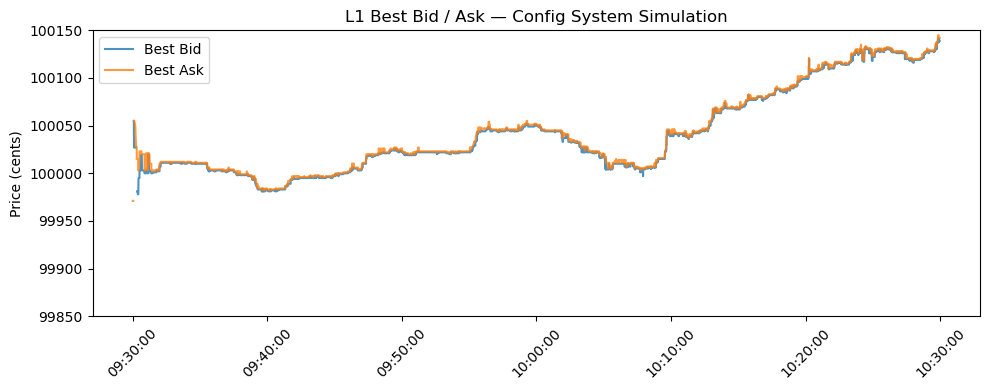

In [42]:
# Extract L1 order book data
order_book = sim_end_state["agents"][0].order_books["ABM"]
L1 = order_book.get_L1_snapshots()

best_bids = pd.DataFrame(L1["best_bids"], columns=["time", "price", "qty"])
best_asks = pd.DataFrame(L1["best_asks"], columns=["time", "price", "qty"])

# Convert time to seconds from midnight for plotting
best_bids["time"] = best_bids["time"].apply(lambda x: x - ns_date(x))
best_asks["time"] = best_asks["time"].apply(lambda x: x - ns_date(x))

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(best_bids.time, best_bids.price, label="Best Bid", alpha=0.8)
ax.plot(best_asks.time, best_asks.price, label="Best Ask", alpha=0.8)

band = 150
ax.set_ylim(100_000 - band, 100_000 + band)
ax.set_ylabel("Price (cents)")
ax.set_title("L1 Best Bid / Ask — Config System Simulation")
ax.legend()

time_mesh = np.arange(str_to_ns("09:30:00"), str_to_ns("10:40:00"), 1e9 * 60 * 10)
ax.set_xticks(time_mesh)
ax.set_xticklabels([fmt_ts(int(t)).split(" ")[1] for t in time_mesh], rotation=45)
plt.tight_layout()
plt.show()

---
## 9. Comparing Old vs. New Config System

The new system produces the exact same runtime dict as `rmsc04.build_config()`.  
Both approaches are fully supported — use whichever fits your workflow.

In [43]:
from collections import Counter

from abides_markets.configs import rmsc04

# Old procedural approach
old_config = rmsc04.build_config(seed=42)
old_types = Counter(type(a).__name__ for a in old_config["agents"])

# New declarative approach
new_config = SimulationBuilder().from_template("rmsc04").seed(42).build()
new_runtime = compile(new_config)
new_types = Counter(type(a).__name__ for a in new_runtime["agents"])

print(f"Old system agent count: {len(old_config['agents'])}")
print(f"New system agent count: {len(new_runtime['agents'])}")
print(f"Agent types match: {old_types == new_types}")
print(f"Runtime dict keys match: {set(old_config.keys()).issubset(set(new_runtime.keys()))}")
print()
print("Agent composition:")
for agent_type, count in sorted(new_types.items()):
    print(f"  {agent_type}: {count}")

Old system agent count: 1117
New system agent count: 1117
Agent types match: True
Runtime dict keys match: True

Agent composition:
  AdaptiveMarketMakerAgent: 2
  ExchangeAgent: 1
  MomentumAgent: 12
  NoiseAgent: 1000
  ValueAgent: 102


---
## 10. Summary

| Feature | How |
|---------|-----|
| Start from template | `SimulationBuilder().from_template("rmsc04")` |
| Override market params | `.market(ticker="AAPL", date="20220315")` |
| Enable/disable agents | `.enable_agent("noise", count=500)` / `.disable_agent("momentum")` |
| Per-agent delays | `.enable_agent("noise", count=500, computation_delay=200)` |
| Stack templates | `.from_template("rmsc04").from_template("with_execution")` |
| Serialize to YAML | `save_config(config, "sim.yaml")` |
| Register custom agent | `@register_agent("my_agent", category="strategy")` |
| AI introspection | `list_agent_types()`, `get_config_schema()` |
| Compile & run | `runtime = compile(config); abides.run(runtime)` |